# Caso 2 — Conteo Automático de Objetos

**Python for Research — Módulo 2: Procesamiento de Imágenes**

Este notebook demuestra un pipeline completo de conteo automático de objetos:

1. Generación de una imagen sintética con conteo real (*ground truth*) conocido
2. Preprocesamiento (escala de grises + reducción de ruido)
3. Binarización: umbral de Otsu (global) vs. umbral adaptativo (local)
4. Operaciones morfológicas de limpieza de la máscara binaria
5. Detección de objetos: contornos externos vs. componentes conexos
6. Separación de objetos superpuestos/tocándose con el algoritmo **Watershed**
7. Comparación cuantitativa de los tres métodos de conteo contra el ground truth
8. Aplicación del pipeline a un dataset real (`skimage.data.coins`)


## 0. Configuración del entorno

In [1]:
import sys
import os

# Permite importar los módulos del pipeline (src/) desde el notebook
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))

import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from skimage import data as skdata

import preprocessing as prep
import segmentation as seg
import detection as det
import counting as cnt

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["image.cmap"] = "gray"

RESULTS_FIGURES = os.path.join("..", "results", "figures")
RESULTS_METRICS = os.path.join("..", "results", "metrics")
os.makedirs(RESULTS_FIGURES, exist_ok=True)
os.makedirs(RESULTS_METRICS, exist_ok=True)

print("Entorno listo. Módulos importados correctamente:",
      prep.__name__, seg.__name__, det.__name__, cnt.__name__)


Entorno listo. Módulos importados correctamente: preprocessing segmentation detection counting


## 1. Generación de datos sintéticos (con ground truth conocido)

Para evaluar cuantitativamente la precisión del conteo se necesita un
valor de referencia (*ground truth*) confiable, algo que rara vez está
disponible en imágenes reales sin anotar. Por eso generamos una imagen
sintética de "partículas" circulares (`skimage`/`OpenCV`) con un número
de objetos conocido de antemano, incluyendo **solapamientos
intencionales** entre partículas — el escenario más exigente para un
pipeline de conteo, y en el que la diferencia entre un conteo ingenuo
(contornos/componentes conexos) y Watershed se hace evidente.


Conteo real (ground truth): 40 partículas
Dimensiones: (400, 400) | dtype: uint8


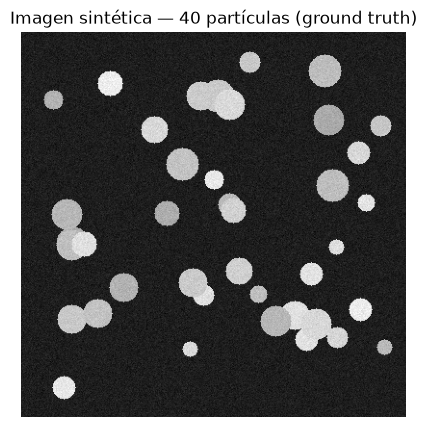

In [2]:
synthetic_image, ground_truth = prep.generate_synthetic_particles(
    image_size=(400, 400),
    num_particles=40,
    radius_range=(8, 18),
    allow_overlap=True,
    noise_sigma=8.0,
    seed=42,
)

print(f"Conteo real (ground truth): {ground_truth['count']} partículas")
print("Dimensiones:", synthetic_image.shape, "| dtype:", synthetic_image.dtype)

plt.figure(figsize=(5, 5))
plt.imshow(synthetic_image, cmap="gray")
plt.title(f"Imagen sintética — {ground_truth['count']} partículas (ground truth)")
plt.axis("off")
plt.savefig(os.path.join(RESULTS_FIGURES, "01_imagen_sintetica.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## 2. Preprocesamiento

Convertimos a escala de grises (la imagen sintética ya lo está, pero el
paso es necesario para imágenes a color reales) y aplicamos un filtro
Gaussiano para reducir ruido antes de binarizar — evita que el ruido de
adquisición se traduzca en pequeños artefactos en la máscara binaria.


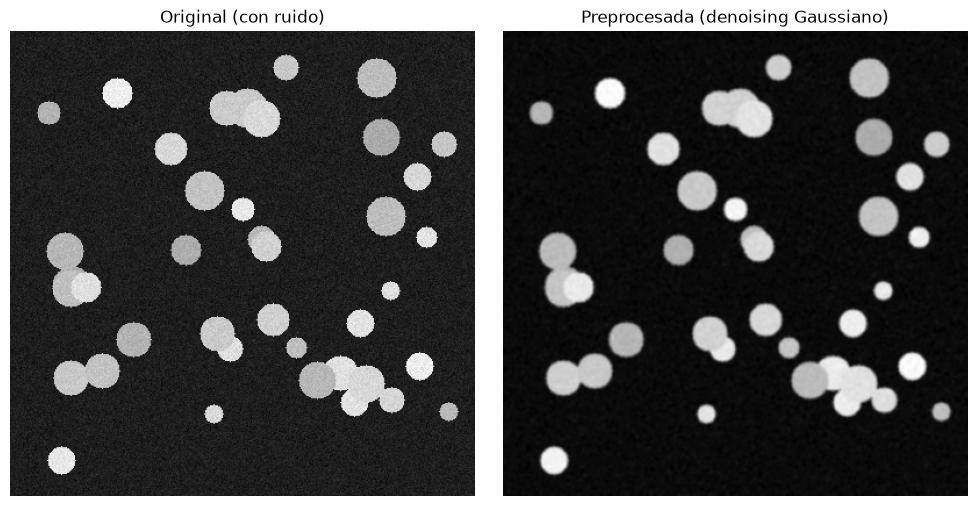

In [3]:
preprocessed = prep.prepare_for_segmentation(
    synthetic_image, denoise_method="gaussian", kernel_size=(5, 5),
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(synthetic_image, cmap="gray")
axes[0].set_title("Original (con ruido)")
axes[0].axis("off")
axes[1].imshow(preprocessed, cmap="gray")
axes[1].set_title("Preprocesada (denoising Gaussiano)")
axes[1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FIGURES, "02_preprocesamiento.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## 3. Binarización: Otsu vs. umbral adaptativo

Comparamos dos estrategias de binarización:

- **Otsu (global)**: calcula automáticamente un único umbral óptimo
  para toda la imagen. Funciona muy bien cuando la iluminación es
  uniforme (como en esta imagen sintética).
- **Adaptativo (local)**: calcula un umbral distinto por cada región
  local de la imagen. Es más robusto ante iluminación no uniforme,
  pero puede ser más sensible a ruido de alta frecuencia.


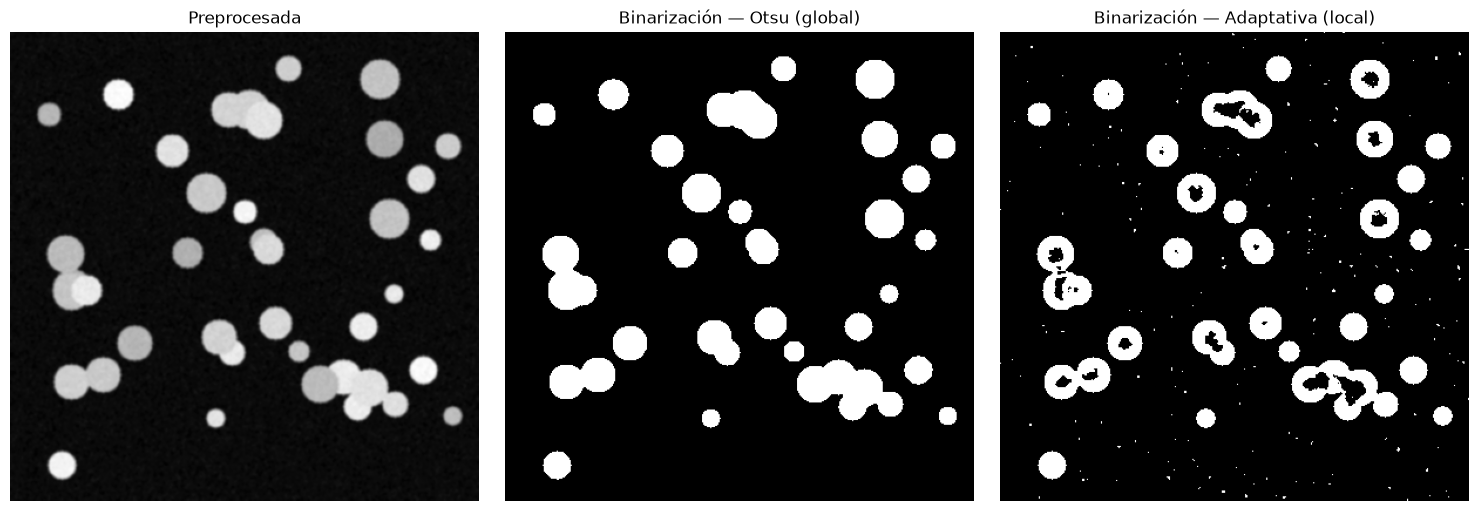

Píxeles en primer plano — Otsu: 20127 | Adaptativa: 18332


In [4]:
otsu_mask = seg.otsu_threshold(preprocessed)
adaptive_mask = seg.adaptive_threshold(preprocessed, method="gaussian",
                                        block_size=31, C=-5)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(preprocessed, cmap="gray")
axes[0].set_title("Preprocesada")
axes[0].axis("off")
axes[1].imshow(otsu_mask, cmap="gray")
axes[1].set_title("Binarización — Otsu (global)")
axes[1].axis("off")
axes[2].imshow(adaptive_mask, cmap="gray")
axes[2].set_title("Binarización — Adaptativa (local)")
axes[2].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FIGURES, "03_binarizacion_otsu_vs_adaptativa.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print("Píxeles en primer plano — Otsu:", int((otsu_mask > 0).sum()),
      "| Adaptativa:", int((adaptive_mask > 0).sum()))


## 4. Operaciones morfológicas

La máscara de Otsu (elegida para el resto del pipeline, por ser la más
limpia en este caso de iluminación uniforme) se limpia con:

1. **Apertura** (erosión + dilatación): elimina ruido puntual aislado.
2. **Cierre** (dilatación + erosión): rellena pequeños huecos internos.
3. **Filtro por área mínima**: descarta componentes residuales muy
   pequeños que sobrevivieron a la apertura.


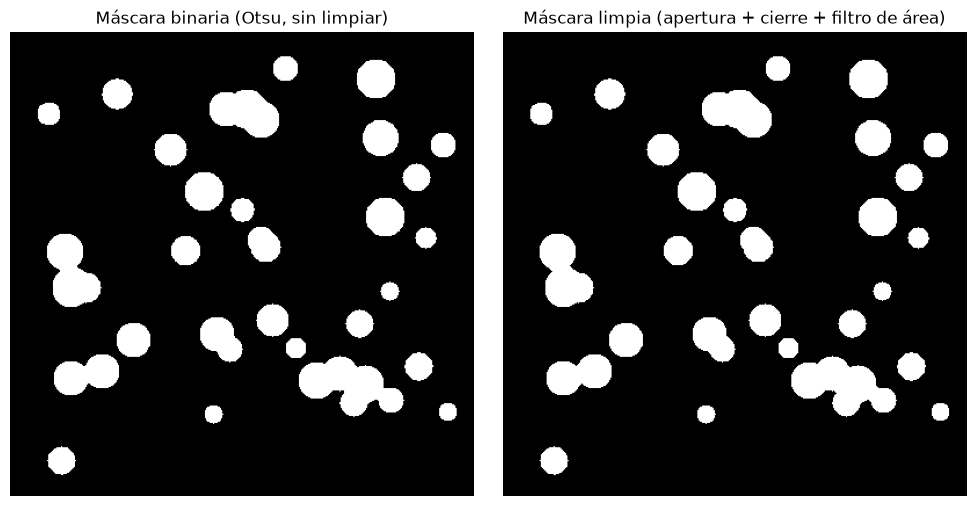

In [5]:
clean_mask = seg.clean_binary_mask(
    otsu_mask, kernel_size=3, open_iterations=1, close_iterations=2, min_area=15,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(otsu_mask, cmap="gray")
axes[0].set_title("Máscara binaria (Otsu, sin limpiar)")
axes[0].axis("off")
axes[1].imshow(clean_mask, cmap="gray")
axes[1].set_title("Máscara limpia (apertura + cierre + filtro de área)")
axes[1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FIGURES, "04_limpieza_morfologica.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## 5. Detección: contornos vs. componentes conexos

Ambos métodos identifican blobs individuales en la máscara binaria,
pero **ninguno separa objetos que se tocan o se superponen**: un grupo
de partículas solapadas se cuenta como un único objeto. Esta limitación
se aborda en la siguiente sección con Watershed.


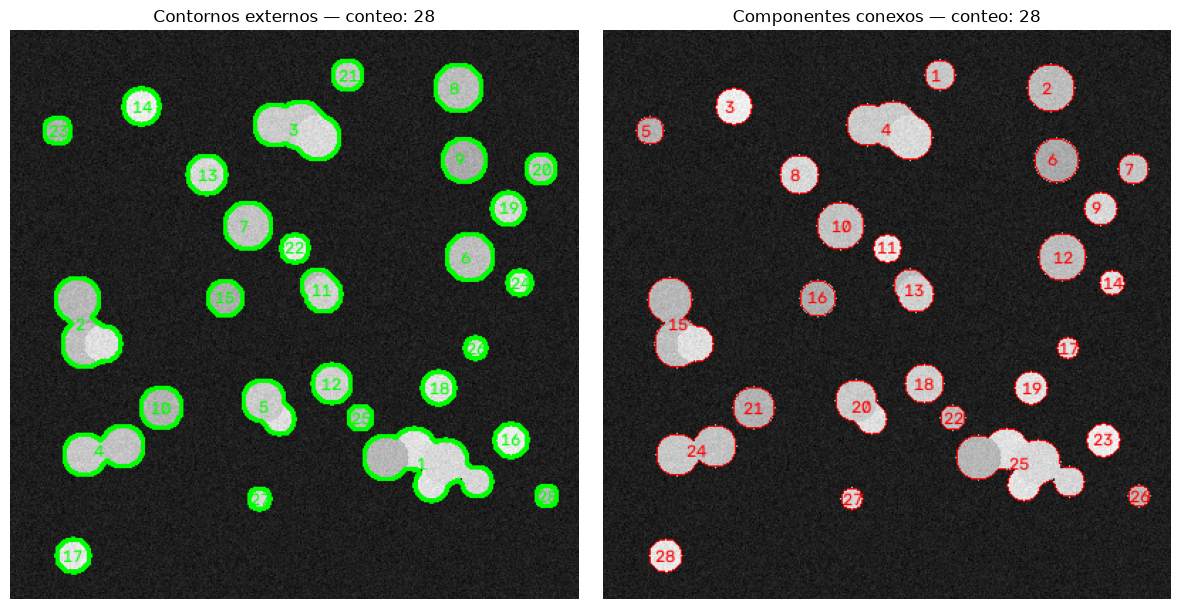

Ground truth: 40  |  Contornos: 28  |  Componentes conexos: 28


In [6]:
result_contours = cnt.count_by_contours(clean_mask, min_area=15)
result_cc = cnt.count_by_connected_components(clean_mask, min_area=15)

vis_contours = det.draw_contours(synthetic_image, result_contours["contours"])
vis_cc = det.draw_labeled_regions(synthetic_image, result_cc["labels"])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(vis_contours, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Contornos externos — conteo: {result_contours['count']}")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(vis_cc, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Componentes conexos — conteo: {result_cc['count']}")
axes[1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FIGURES, "05_deteccion_contornos_vs_componentes.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Ground truth: {ground_truth['count']}  |  "
      f"Contornos: {result_contours['count']}  |  "
      f"Componentes conexos: {result_cc['count']}")


## 6. Watershed — separación de objetos superpuestos

Watershed usa la transformada de distancia (distancia de cada píxel de
primer plano al borde más cercano) para encontrar un "centro" (máximo
local) por cada objeto, y hace crecer regiones desde esos centros hasta
que se encuentran — generando así una frontera entre partículas
adyacentes que los métodos anteriores fusionaban en un único blob.


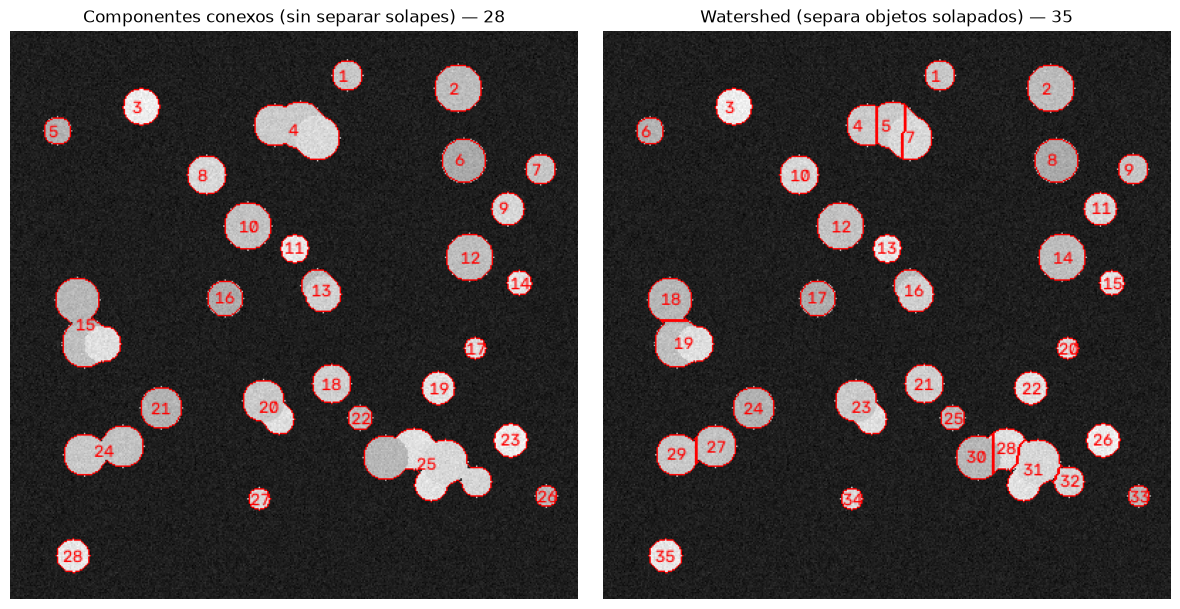

In [7]:
result_watershed = cnt.count_by_watershed(clean_mask, min_distance=8)

vis_watershed = det.draw_labeled_regions(synthetic_image, result_watershed["labels"],
                                          boundary_color=(0, 0, 255))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(vis_cc, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Componentes conexos (sin separar solapes) — {result_cc['count']}")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(vis_watershed, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Watershed (separa objetos solapados) — {result_watershed['count']}")
axes[1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FIGURES, "06_watershed.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## 7. Comparación cuantitativa de métodos de conteo

Como se conoce el ground truth de la imagen sintética, podemos calcular
el error absoluto y relativo de cada método de conteo.


In [8]:
counting_results = {
    "contornos": result_contours["count"],
    "componentes_conexos": result_cc["count"],
    "watershed": result_watershed["count"],
}

report = cnt.build_counting_report(counting_results, ground_truth=ground_truth["count"])
report


,method,count,ground_truth,abs_error,rel_error_%
0,watershed,35,40,5,12.5
1,contornos,28,40,12,30.0
2,componentes_conexos,28,40,12,30.0


In [9]:
csv_path = os.path.join(RESULTS_METRICS, "case2_counting_comparison.csv")
report.to_csv(csv_path, index=False)
print(f"Tabla de conteo guardada en: {csv_path}")


Tabla de conteo guardada en: ..\results\metrics\case2_counting_comparison.csv


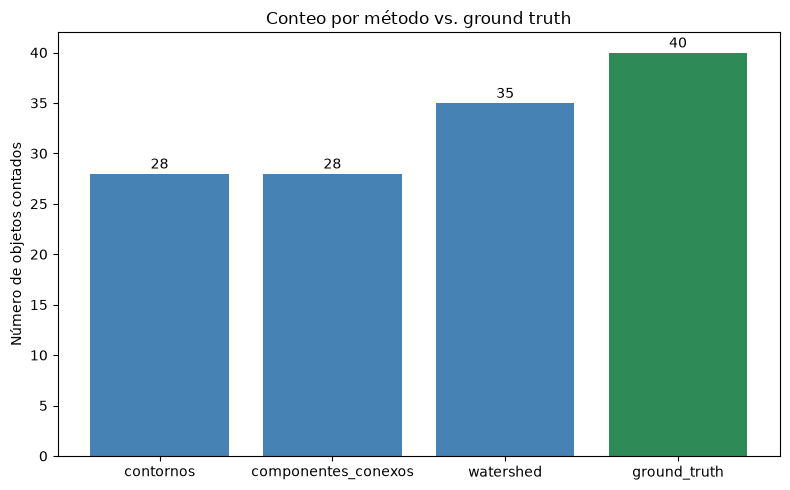

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
methods = list(counting_results.keys()) + ["ground_truth"]
counts = list(counting_results.values()) + [ground_truth["count"]]
colors = ["steelblue", "steelblue", "steelblue", "seagreen"]

ax.bar(methods, counts, color=colors)
ax.set_ylabel("Número de objetos contados")
ax.set_title("Conteo por método vs. ground truth")
for i, v in enumerate(counts):
    ax.text(i, v + 0.5, str(v), ha="center")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FIGURES, "07_conteo_comparativo.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## 8. Aplicación a un dataset real: `skimage.data.coins`

Para validar que el pipeline generaliza más allá de la imagen
sintética, lo aplicamos a `skimage.data.coins()` — una fotografía real
de 24 monedas sobre una superficie, un caso clásico de conteo de
objetos en visión por computador clásica.

A diferencia de la imagen sintética, esta fotografía tiene **iluminación
no uniforme** (un leve gradiente de brillo hacia los bordes). Un Otsu
"ingenuo" sobre la imagen preprocesada fusiona ese gradiente de fondo
con las monedas de la fila superior en un único blob gigante que toca
el borde de la imagen, arruinando el conteo. Para corregirlo:

- Se aplica **CLAHE** antes de Otsu, para atenuar el gradiente de
  iluminación (igual que en la Sección 3, un umbral global funciona mal
  ante iluminación no uniforme).
- Se descartan los componentes que **tocan el borde** de la imagen
  (`clear_border_objects`), ya que suelen ser monedas parcialmente
  cortadas por el encuadre (área real desconocida) o remanentes del
  gradiente de iluminación — práctica estándar en conteo sobre datos
  reales.


Dimensiones: (303, 384) | dtype: uint8


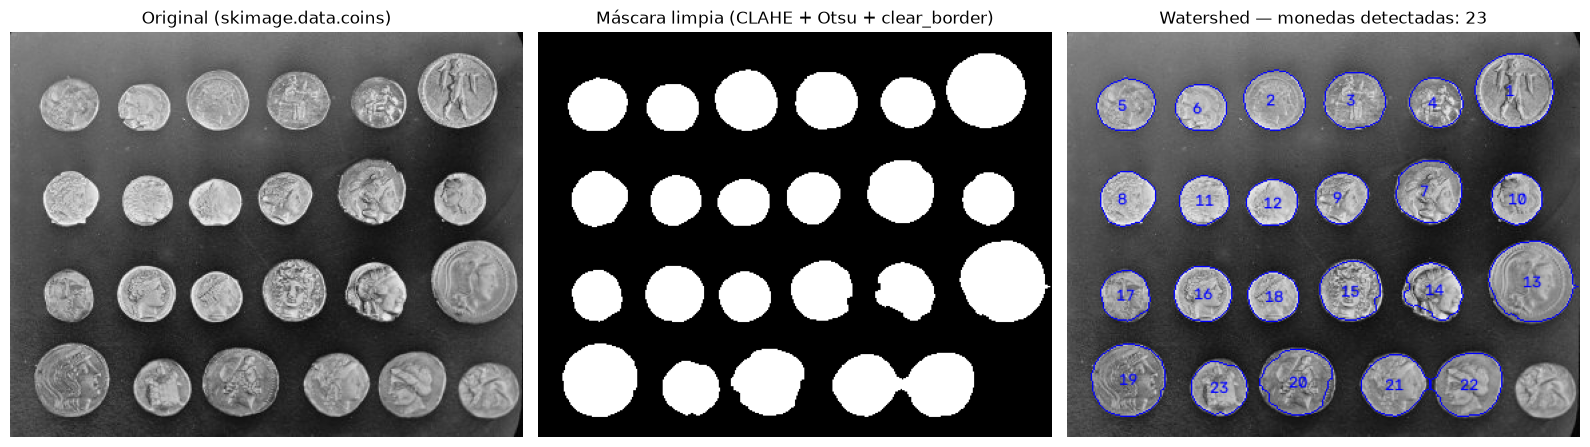

Monedas completamente visibles detectadas por Watershed: 23
(El dataset tiene 24 monedas en total; las que quedan cortadas por el borde del encuadre se excluyen intencionalmente del conteo.)


In [11]:
coins_image = skdata.coins()
print("Dimensiones:", coins_image.shape, "| dtype:", coins_image.dtype)

coins_pre = prep.prepare_for_segmentation(
    coins_image, denoise_method="median", kernel_size=5, apply_clahe=True,
)
coins_mask = seg.otsu_threshold(coins_pre)
coins_clean = seg.clean_binary_mask(coins_mask, kernel_size=5, close_iterations=2, min_area=200)
coins_clean = seg.clear_border_objects(coins_clean)
coins_watershed = cnt.count_by_watershed(coins_clean, min_distance=20)

vis_coins = det.draw_labeled_regions(coins_image, coins_watershed["labels"],
                                      boundary_color=(255, 0, 0))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(coins_image, cmap="gray")
axes[0].set_title("Original (skimage.data.coins)")
axes[0].axis("off")
axes[1].imshow(coins_clean, cmap="gray")
axes[1].set_title("Máscara limpia (CLAHE + Otsu + clear_border)")
axes[1].axis("off")
axes[2].imshow(cv2.cvtColor(vis_coins, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Watershed — monedas detectadas: {coins_watershed['count']}")
axes[2].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FIGURES, "08_dataset_real_coins.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Monedas completamente visibles detectadas por Watershed: {coins_watershed['count']}")
print("(El dataset tiene 24 monedas en total; las que quedan cortadas por el "
      "borde del encuadre se excluyen intencionalmente del conteo.)")


## 9. Discusión de resultados

- **Otsu vs. adaptativo**: en esta imagen sintética con fondo
  relativamente uniforme, Otsu produce una máscara más limpia; el
  umbral adaptativo tiende a introducir ruido de alta frecuencia en
  regiones sin objetos cuando la iluminación ya es uniforme, aunque
  sería preferible ante iluminación desigual (sombras, viñeteo, etc.).
- **Contornos vs. componentes conexos**: ambos métodos producen
  conteos prácticamente idénticos entre sí, y ambos **subestiman**
  sistemáticamente el conteo real, ya que fusionan en un solo objeto
  cualquier grupo de partículas que se tocan o se superponen.
- **Watershed**: se acerca notablemente más al ground truth al separar
  explícitamente objetos adyacentes mediante la transformada de
  distancia y la detección de máximos locales, aunque no es perfecto:
  partículas muy solapadas (con un único máximo de distancia dominante)
  pueden seguir contándose como una sola.
- **Generalización**: el mismo pipeline (preprocesamiento → Otsu →
  limpieza morfológica → Watershed) se aplicó a `skimage.data.coins()`
  ajustando parámetros (kernel, área mínima, `min_distance`) y
  agregando dos pasos adicionales — CLAHE y `clear_border_objects` —,
  lo que confirma que el diseño modular del pipeline es reutilizable
  entre datasets sintéticos y reales, aunque los datos reales suelen
  requerir pasos extra para manejar iluminación no uniforme y objetos
  cortados por el encuadre.
